<a href="https://colab.research.google.com/github/JoseCamachoS/Metodos-nunericos-l/blob/main/metododepuntofijo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="cyan">**Método de punto fijo**</font>

# Método de Punto Fijo para la Búsqueda de Raíces

El **método de punto fijo** es un algoritmo numérico iterativo para hallar las raíces de una ecuación en un intervalo [a,b]



El método transforma la ecuación original $f(x) = 0$ en una ecuación equivalente de la forma $g(x) = x$

Un valor $p$ tal que $g(p) = p$ se denomina **punto fijo** de la función $g$.


Dado un valor inicial $p_0$:

$p_1 = g(p_0)$.

$p_2 = g(p_1)$.

Y en general $p_{n+1} = g(p_n), \quad n = 0, 1, 2, \dots$

El proceso se repite hasta que $\vert{}p_{n+1} - p_n\vert{} < \epsilon$= a una toleracia o hasta alcanzar un número máximo de iteraciones.

<font color="cyan">convergencia</font>

Según el **Teorema del Punto Fijo**, la secuencia $\{x_n\}$ se aproxima a la raíz $p$ en el intervalo [a,b] si cumple que $g(x)$ es diferenciable en (a,b) y además

$$\vert{}g'(x)\vert{} \le k < 1$$

 **Si $\vert{}g'(p)\vert{} < 1$**: El método converge a la raíz.

 **Si $\vert{}g'(p)\vert{} > 1$**: El método diverge.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # para crear  la tabla mas adelante
# se importan las librerias necesarias

definimos $f(x)=x^3 + 4x^2 -10$=0, esta funcion debe estar igualada a cero
1.Pasamos el término independiente $10$ al lado derecho:
   $$x^3 + 4x^2 = 10$$

2.Factorizamos el término $x^2$ en el lado izquierdo:
   $$x^2(x + 4) = 10$$

3.Despejamos $x^2$ dividiendo entre $(x + 4)$:
   $$x^2 = \frac{10}{x + 4}$$

4.Elevamos ambos miembros a la potencia $\frac{1}{2}$ (o aplicamos raíz cuadrada) para despejar $x$:
   $$x = \left(\frac{10}{x + 4}\right)^{\frac{1}{2}}$$


**Análisis de Convergencia para $g(x) = \left(\frac{10}{x + 4}\right)^{\frac{1}{2}}$**

Para garantizar que el método de punto fijo converja a la raíz $p$, se debe cumplir el criterio del **Teorema del Punto Fijo**:

$$|g'(x)| < 1$$





**Cálculo de la derivada $g'(x)$**

Reescribimos $g(x)$ usando exponentes:

$$g(x) = 10^{\frac{1}{2}} (x + 4)^{-\frac{1}{2}}$$

Aplicando la regla de la cadena para derivar:

$$g'(x) = 10^{\frac{1}{2}} \left(-\frac{1}{2}\right) (x + 4)^{-\frac{3}{2}} = -\frac{\sqrt{10}}{2 (x + 4)^{\frac{3}{2}}}$$

**Acotamiento de $|g'(x)|$ en el intervalo $[1, 2]$**

Como el denominador $(x + 4)^{\frac{3}{2}}$ **crece** a medida que $x$ aumenta, el valor de $|g'(x)|$ alcanza su **máximo valor posible** en el punto más pequeño del intervalo ($x = 1$).

Evaluamos el peor caso posible ($x = 1$):

$$|g'(1)| = \frac{\sqrt{10}}{2(1 + 4)^{\frac{3}{2}}} = \frac{\sqrt{10}}{2(5)^{\frac{3}{2}}} = \frac{\sqrt{10}}{2(5\sqrt{5})} = \frac{\sqrt{2}}{10} \approx 0.1414$$

Por lo tanto, para cualquier valor de $x$ dentro del intervalo $[1, 2]$:

$$|g'(x)| \le 0.1414 < 1$$

 **Por lo tanto esta función es convergente:** La secuencia de valores $x_{k+1} = g(x_k)$ se aproximará a la raíz rápidamente.


In [6]:
def f(x):
  return x**3 + 4*x**2 -10.0

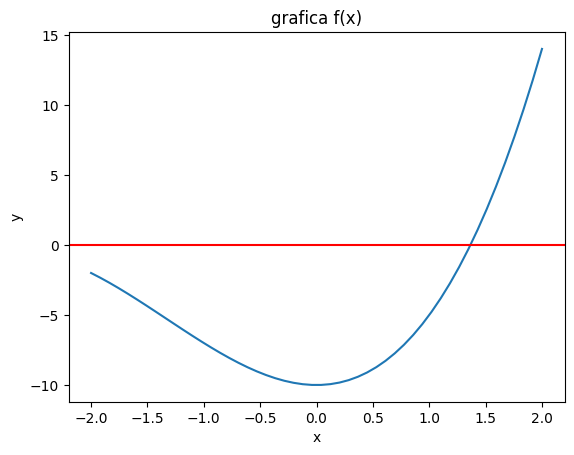

In [8]:
xx=np.linspace(-2,2) #genera una particion
plt.plot(xx,f(xx))#muestra las parejas ordendas, (x,y)
plt.title('grafica f(x)')#titulo superior de la gráfica
plt.xlabel('x')
plt.ylabel('y')

plt.axhline(y=0,color='red')#trazar linea horizontal en Y=0


ahora definimos $g(x) = \left(\frac{10}{x + 4}\right)^{\frac{1}{2}}$


In [9]:
def g(x):
  return np.sqrt(10 / (x + 4))

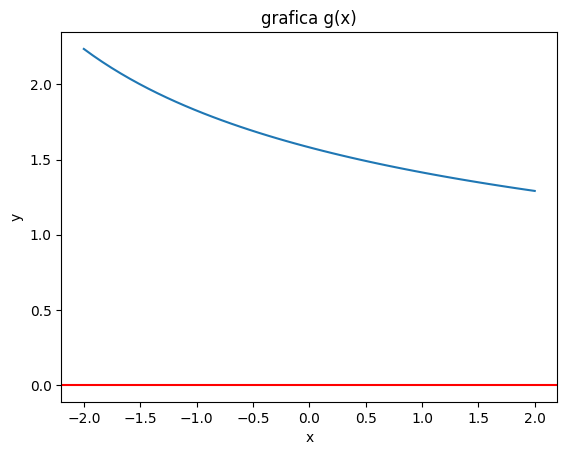

In [16]:
x=np.linspace(-2,2) #genera una particion
plt.plot(x,g(x))#muestra las parejas ordendas, (x,y)
plt.title('grafica g(x)')#titulo superior de la gráfica
plt.xlabel('x')
plt.ylabel('y')

plt.axhline(y=0,color='red')


In [23]:
#creamos uan fucnion para realizar el método
def pfijo(p0,i):
  lista=[]# almacenara lso valores para p0,p1,...pn
  error=[] #almacenara los valores de los errores
  iteraciones = []#almacenará el numero de iteraciones
  for i in range(i):

    p1=g(p0) # formula del metodo
    iteraciones.append(i+1)
    lista.append(p1)
    e=np.abs(p1-p0)
    error.append(e)
    p0=p1

  # Creamos un DataFrame de Pandas para mostrar la tabla
  df = pd.DataFrame({
      'Iteración (i)': iteraciones,
      'p_i': lista,
      'Error |p_i - p_{i-1}|': error
    })

  return df




In [26]:
resultado= pfijo(0.5,30)# ejecutamos la funcion del metodo fando el valor inicial a p0=0.5 y con un maximo de 30 iteraciones


In [27]:
print(resultado) # y por ultimo imprimimos la tabla del metodo de punto fijo

    Iteración (i)       p_i  Error |p_i - p_{i-1}|
0               1  1.490712           9.907120e-01
1               2  1.349540           1.411723e-01
2               3  1.367231           1.769096e-02
3               4  1.364976           2.255128e-03
4               5  1.365262           2.868486e-04
5               6  1.365226           3.649671e-05
6               7  1.365231           4.643436e-06
7               8  1.365230           5.907819e-07
8               9  1.365230           7.516482e-08
9              10  1.365230           9.563176e-09
10             11  1.365230           1.216717e-09
11             12  1.365230           1.548022e-10
12             13  1.365230           1.969536e-11
13             14  1.365230           2.505773e-12
14             15  1.365230           3.188561e-13
15             16  1.365230           4.063416e-14
16             17  1.365230           5.107026e-15
17             18  1.365230           4.440892e-16
18             19  1.365230    